In [1]:
import uproot
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import awkward as ak
import mplhep as hep
import zfit

/home/tandrade/.local/lib/python3.9/site-packages/zfit/__init__.py:63: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress the TensorFlow warnings AND this warning, set ZFIT_DISABLE_TF_WARNINGS=1.
  warnings.warn(


In [2]:
signal_path = "/home/tandrade/Flavour_Anomalies/Data/MC_NonRessonant.root"
tree_name   = "tree_ML"

In [3]:
signal_file = uproot.open(signal_path)[tree_name]
signal_ak = signal_file.arrays(library="ak")
df = ak.to_dataframe(signal_ak)

In [4]:
cut_mass_B = (df['BToTrkTrkMuMu_fit_mass_Kpi_good'] > 5.0) & (df['BToTrkTrkMuMu_fit_mass_Kpi_good'] < 5.6)
cut_mass_MuMu = ( ((df['MuMu_mass_idx_good'] > 1.0) & (df['MuMu_mass_idx_good'] < 2.9)) | ((df['MuMu_mass_idx_good'] > 4.0) & (df['MuMu_mass_idx_good'] < 4.8)) )
final_cut = cut_mass_B & cut_mass_MuMu

In [5]:
df = df[final_cut]

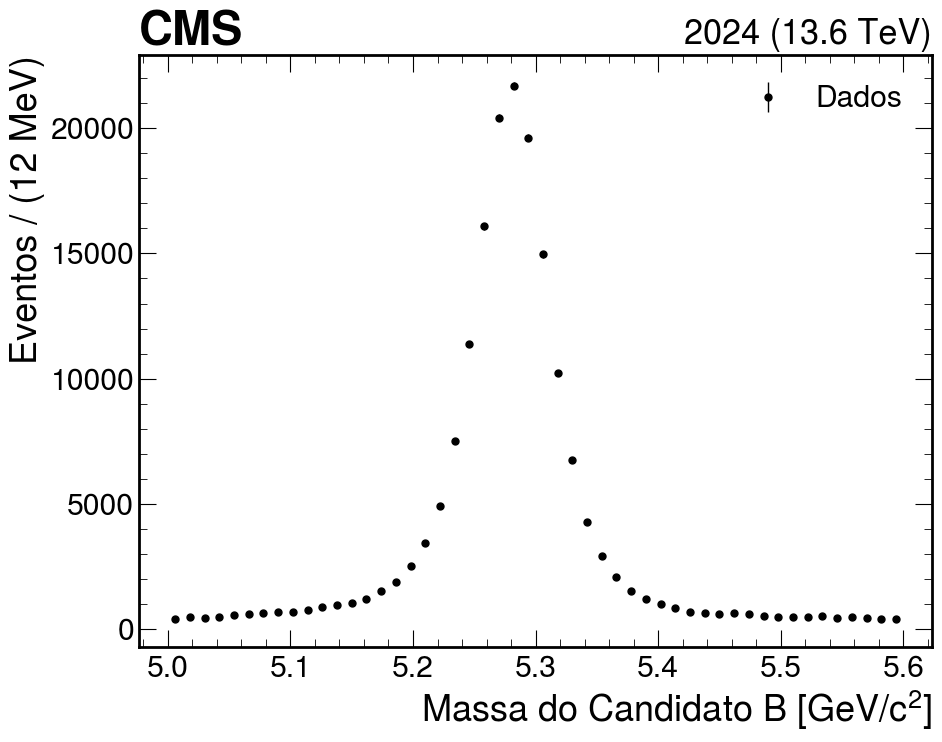

In [6]:
hep.style.use(hep.style.ROOT)
counts, edges = np.histogram(df['BToTrkTrkMuMu_fit_mass_Kpi_good'], bins=50, range=(5.0, 5.6))
fig, ax = plt.subplots(figsize=(10, 8))


hep.histplot(counts, bins=edges, yerr=True, color='black', histtype='errorbar', label='Dados', ax=ax)
ax.set_xlabel(r'Massa do Candidato $B$ [GeV/$c^2$]')
ax.set_ylabel(r'Eventos / (12 MeV)') 
hep.label.exp_label(exp="CMS", data=True, year=2024, com = 13.6, loc=0) 

plt.legend()
plt.tight_layout()
plt.show()
plt.close()

Fit válido: True
name       value  (rounded)        hesse    at limit
-------  ------------------  -----------  ----------
frac               0.581722  +/-   0.018       False
mu                  5.28068  +/- 0.00013       False
sigma             0.0313342  +/- 0.00016       False
alpha_l             1.16877  +/-    0.03       False
n_l                 1.37571  +/-   0.042       False
alpha_r            -1.14714  +/-   0.041       False
n_r                 1.06952  +/-   0.035       False


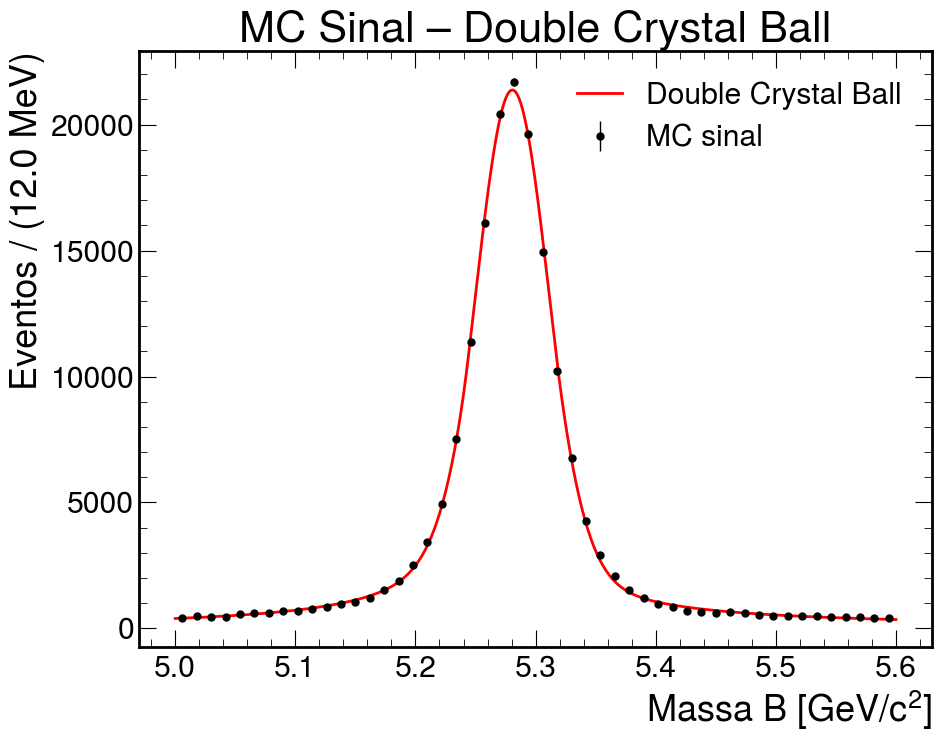

In [7]:
import zfit
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep

hep.style.use(hep.style.ROOT)

# ---------------------------------------------------------
# Dados
# ---------------------------------------------------------
data_array = df['BToTrkTrkMuMu_fit_mass_Kpi_good'].to_numpy()

obs = zfit.Space('mass', limits=(5.0, 5.6))
data = zfit.Data.from_numpy(obs=obs, array=data_array)

# ---------------------------------------------------------
# Parâmetros comuns
# ---------------------------------------------------------
mu = zfit.Parameter("mu", 5.28, 5.25, 5.31)
sigma = zfit.Parameter("sigma", 0.030, 0.005, 0.100)

# ---------------------------------------------------------
# Cauda esquerda
# ---------------------------------------------------------
alpha_l = zfit.Parameter("alpha_l", 1.5, 0.3, 5.0)
n_l = zfit.Parameter("n_l", 5.0, 0.5, 50.0)

cb_left = zfit.pdf.CrystalBall(
    mu=mu,
    sigma=sigma,
    alpha=alpha_l,
    n=n_l,
    obs=obs
)

# ---------------------------------------------------------
# Cauda direita (espelhada)
# ---------------------------------------------------------
alpha_r = zfit.Parameter("alpha_r", -2.0, -5.0, -0.3)
n_r = zfit.Parameter("n_r", 5.0, 0.5, 50.0)

cb_right = zfit.pdf.CrystalBall(
    mu=mu,
    sigma=sigma,
    alpha=alpha_r,
    n=n_r,
    obs=obs
)

# ---------------------------------------------------------
# Soma (fração fixa ou livre)
# ---------------------------------------------------------
frac = zfit.Parameter("frac", 0.5, 0.0, 1.0)

signal_pdf = zfit.pdf.SumPDF(
    [cb_left, cb_right],
    fracs=frac
)

# ---------------------------------------------------------
# Fit (UNBINNED)
# ---------------------------------------------------------
nll = zfit.loss.UnbinnedNLL(
    model=signal_pdf,
    data=data
)

minimizer = zfit.minimize.Minuit()
result = minimizer.minimize(nll)
result.hesse()

print("Fit válido:", result.valid)
print(result.params)

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))

nbins = 50
counts, edges = np.histogram(data_array, bins=nbins, range=(5.0, 5.6))
bin_width = edges[1] - edges[0]

hep.histplot(
    counts,
    bins=edges,
    yerr=True,
    histtype='errorbar',
    color='black',
    label='MC sinal'
)

x_plot = np.linspace(5.0, 5.6, 1000)
pdf_y = signal_pdf.pdf(x_plot).numpy() * len(data_array) * bin_width

plt.plot(x_plot, pdf_y, color='red', lw=2, label='Double Crystal Ball')

plt.xlabel(r'Massa $B$ [GeV/$c^2$]')
plt.ylabel(f'Eventos / ({bin_width*1000:.1f} MeV)')
plt.title('MC Sinal – Double Crystal Ball')
plt.legend()

plt.tight_layout()
plt.show()
plt.close()


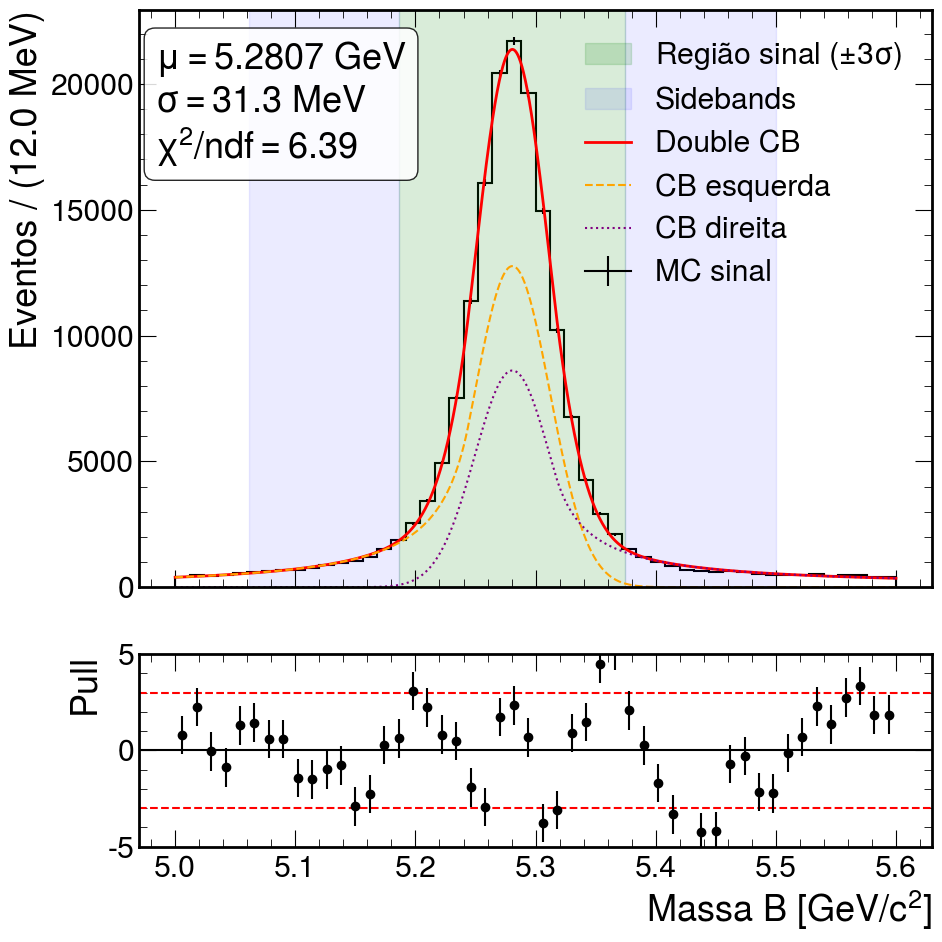

In [8]:
import zfit
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep

hep.style.use(hep.style.ROOT)

# ---------------------------------------------------------
# Dados
# ---------------------------------------------------------
data_array = df['BToTrkTrkMuMu_fit_mass_Kpi_good'].to_numpy()

obs = zfit.Space('mass', limits=(5.0, 5.6))
data = zfit.Data.from_numpy(obs=obs, array=data_array)

# ---------------------------------------------------------
# Double Crystal Ball
# ---------------------------------------------------------
mu = zfit.Parameter("mu", 5.28, 5.25, 5.31)
sigma = zfit.Parameter("sigma", 0.030, 0.005, 0.100)

alpha_l = zfit.Parameter("alpha_l", 1.5, 0.3, 5.0)
n_l = zfit.Parameter("n_l", 5.0, 0.5, 50.0)

alpha_r = zfit.Parameter("alpha_r", -2.0, -5.0, -0.3)
n_r = zfit.Parameter("n_r", 5.0, 0.5, 50.0)

cb_left = zfit.pdf.CrystalBall(mu, sigma, alpha_l, n_l, obs=obs)
cb_right = zfit.pdf.CrystalBall(mu, sigma, alpha_r, n_r, obs=obs)

frac = zfit.Parameter("frac", 0.5, 0.0, 1.0)

signal_pdf = zfit.pdf.SumPDF([cb_left, cb_right], fracs=frac)

# ---------------------------------------------------------
# Fit
# ---------------------------------------------------------
nll = zfit.loss.UnbinnedNLL(signal_pdf, data)
minimizer = zfit.minimize.Minuit()
result = minimizer.minimize(nll)
result.hesse()

# ---------------------------------------------------------
# Histogramas
# ---------------------------------------------------------
nbins = 50
counts, edges = np.histogram(data_array, bins=nbins, range=(5.0, 5.6))
centers = 0.5 * (edges[:-1] + edges[1:])
bin_width = edges[1] - edges[0]
errors = np.sqrt(counts)

# ---------------------------------------------------------
# Modelo nos bins
# ---------------------------------------------------------
x_plot = np.linspace(5.0, 5.6, 2000)

total_y = signal_pdf.pdf(x_plot).numpy() * len(data_array) * bin_width
left_y = cb_left.pdf(x_plot).numpy() * frac.value() * len(data_array) * bin_width
right_y = cb_right.pdf(x_plot).numpy() * (1 - frac.value()) * len(data_array) * bin_width

# Valores do modelo nos centros dos bins
model_bins = signal_pdf.pdf(centers).numpy() * len(data_array) * bin_width

# ---------------------------------------------------------
# Chi2 / ndf
# ---------------------------------------------------------
mask = counts > 0
chi2 = np.sum(((counts[mask] - model_bins[mask]) / errors[mask])**2)
ndf = np.sum(mask) - len(result.params)
chi2_ndf = chi2 / ndf

# ---------------------------------------------------------
# Regiões em sigma
# ---------------------------------------------------------
mu_val = mu.value()
sig_val = sigma.value()

sig_l = mu_val - 3 * sig_val
sig_r = mu_val + 3 * sig_val

sb_l1 = mu_val - 7 * sig_val
sb_l2 = mu_val - 3 * sig_val
sb_r1 = mu_val + 3 * sig_val
sb_r2 = mu_val + 7 * sig_val

# ---------------------------------------------------------
# Plot (fit + pull)
# ---------------------------------------------------------
fig, (ax, ax_pull) = plt.subplots(
    2, 1, figsize=(10, 10),
    gridspec_kw={"height_ratios": [3, 1]},
    sharex=True
)

# --- Dados
hep.histplot(counts, edges, yerr=True, ax=ax, color='black', label='MC sinal')

# --- Regiões
ax.axvspan(sig_l, sig_r, color='green', alpha=0.15, label=r'Região sinal ($\pm3\sigma$)')
ax.axvspan(sb_l1, sb_l2, color='blue', alpha=0.08, label='Sidebands')
ax.axvspan(sb_r1, sb_r2, color='blue', alpha=0.08)

# --- Curvas
ax.plot(x_plot, total_y, color='red', lw=2, label='Double CB')
ax.plot(x_plot, left_y, color='orange', ls='--', label='CB esquerda')
ax.plot(x_plot, right_y, color='purple', ls=':', label='CB direita')

# --- Texto
text = (
    rf"$\mu = {mu_val:.4f}$ GeV" "\n"
    rf"$\sigma = {sig_val*1000:.1f}$ MeV" "\n"
    rf"$\chi^2/\mathrm{{ndf}} = {chi2_ndf:.2f}$"
)

ax.text(
    0.02, 0.95, text,
    transform=ax.transAxes,
    va='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.85)
)

ax.set_ylabel(f'Eventos / ({bin_width*1000:.1f} MeV)')
ax.legend()

# ---------------------------------------------------------
# Pull plot
# ---------------------------------------------------------
pulls = np.zeros_like(counts, dtype=float)
pulls[mask] = (counts[mask] - model_bins[mask]) / errors[mask]

ax_pull.axhline(0, color='black')
ax_pull.axhline( 3, color='red', ls='--')
ax_pull.axhline(-3, color='red', ls='--')

ax_pull.errorbar(
    centers,
    pulls,
    yerr=np.ones_like(pulls),
    fmt='o',
    color='black'
)

ax_pull.set_ylim(-5, 5)
ax_pull.set_ylabel('Pull')
ax_pull.set_xlabel(r'Massa $B$ [GeV/$c^2$]')

plt.tight_layout()
plt.show()

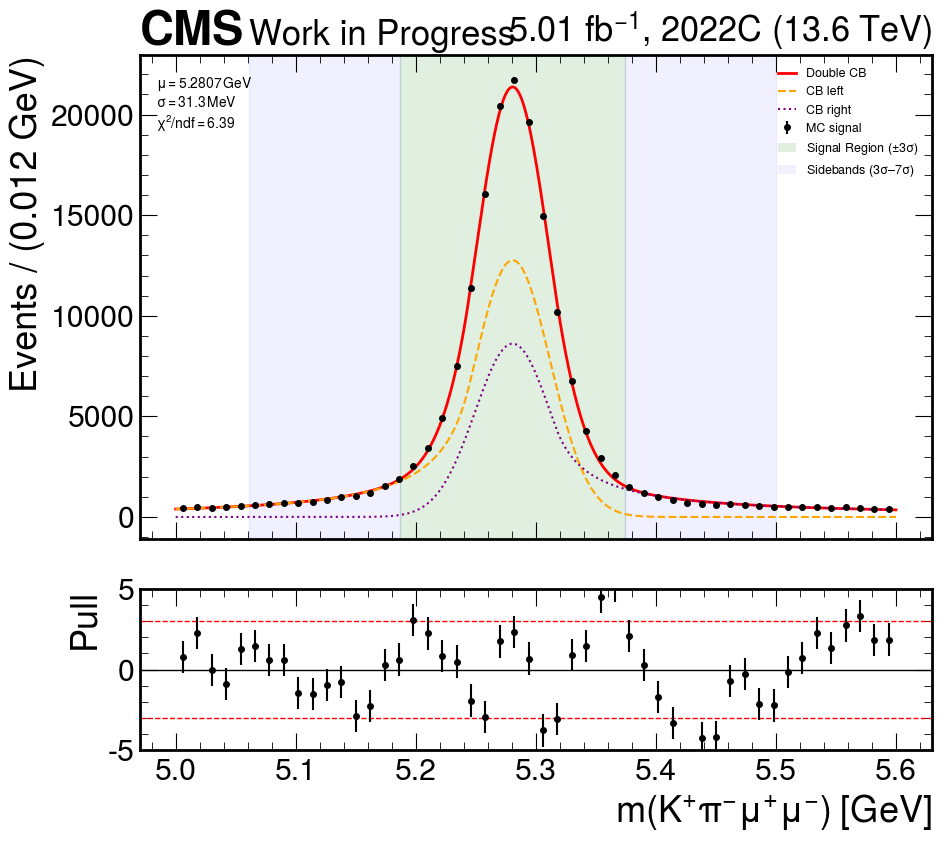

In [11]:
import zfit
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
from matplotlib.patches import Patch

hep.style.use(hep.style.ROOT)

# =========================================================
# Dados
# =========================================================
data_array = df['BToTrkTrkMuMu_fit_mass_Kpi_good'].to_numpy()

obs = zfit.Space('mass', limits=(5.0, 5.6))
data = zfit.Data.from_numpy(obs=obs, array=data_array)

# =========================================================
# Double Crystal Ball
# =========================================================
mu = zfit.Parameter("mu", 5.28, 5.25, 5.31)
sigma = zfit.Parameter("sigma", 0.030, 0.005, 0.100)

alpha_l = zfit.Parameter("alpha_l", 1.5, 0.3, 5.0)
n_l = zfit.Parameter("n_l", 5.0, 0.5, 50.0)

alpha_r = zfit.Parameter("alpha_r", -2.0, -5.0, -0.3)
n_r = zfit.Parameter("n_r", 5.0, 0.5, 50.0)

cb_left = zfit.pdf.CrystalBall(mu, sigma, alpha_l, n_l, obs=obs)
cb_right = zfit.pdf.CrystalBall(mu, sigma, alpha_r, n_r, obs=obs)

frac = zfit.Parameter("frac", 0.5, 0.0, 1.0)

signal_pdf = zfit.pdf.SumPDF([cb_left, cb_right], fracs=frac)

# =========================================================
# Fit
# =========================================================
nll = zfit.loss.UnbinnedNLL(signal_pdf, data)
minimizer = zfit.minimize.Minuit()
result = minimizer.minimize(nll)
result.hesse()

# =========================================================
# Histogramas
# =========================================================
nbins = 50
counts, edges = np.histogram(data_array, bins=nbins, range=(5.0, 5.6))
centers = 0.5 * (edges[:-1] + edges[1:])
bin_width = edges[1] - edges[0]
errors = np.sqrt(counts)

# =========================================================
# Modelo
# =========================================================
x_plot = np.linspace(5.0, 5.6, 2000)

N = len(data_array)
total_y = signal_pdf.pdf(x_plot).numpy() * N * bin_width
left_y = cb_left.pdf(x_plot).numpy() * frac.value() * N * bin_width
right_y = cb_right.pdf(x_plot).numpy() * (1 - frac.value()) * N * bin_width

model_bins = signal_pdf.pdf(centers).numpy() * N * bin_width

# =========================================================
# Chi2 / ndf
# =========================================================
mask = counts > 0
chi2 = np.sum(((counts[mask] - model_bins[mask]) / errors[mask])**2)
ndf = np.sum(mask) - len(result.params)
chi2_ndf = chi2 / ndf

# =========================================================
# Regiões em sigma
# =========================================================
mu_val = mu.value()
sig_val = sigma.value()

sig_l = mu_val - 3 * sig_val
sig_r = mu_val + 3 * sig_val

sb_l1 = mu_val - 7 * sig_val
sb_l2 = mu_val - 3 * sig_val
sb_r1 = mu_val + 3 * sig_val
sb_r2 = mu_val + 7 * sig_val

# =========================================================
# Plot
# =========================================================
fig, (ax, ax_pull) = plt.subplots(
    2, 1,
    figsize=(10, 9),
    gridspec_kw={"height_ratios": [3, 1]},
    sharex=True
)

# --- Dados (pontos)
ax.errorbar(
    centers, counts, yerr=errors,
    fmt='o', color='black',
    markersize=4, label='MC signal'
)

# --- Regiões (sem label direto)
ax.axvspan(sig_l, sig_r, color='green', alpha=0.12)
ax.axvspan(sb_l1, sb_l2, color='blue', alpha=0.06)
ax.axvspan(sb_r1, sb_r2, color='blue', alpha=0.06)

# --- Curvas
ax.plot(x_plot, total_y, color='red', lw=2, label='Double CB')
ax.plot(x_plot, left_y, color='orange', ls='--', lw=1.5, label='CB left')
ax.plot(x_plot, right_y, color='purple', ls=':', lw=1.5, label='CB right')

# --- Texto pequeno, sem caixa
text = (
    rf"$\mu = {mu_val:.4f}\,\mathrm{{GeV}}$" "\n"
    rf"$\sigma = {sig_val*1000:.1f}\,\mathrm{{MeV}}$" "\n"
    rf"$\chi^2/\mathrm{{ndf}} = {chi2_ndf:.2f}$"
)

ax.text(0.02, 0.96, text, transform=ax.transAxes,
        fontsize=10, va='top')

ax.set_ylabel(f'Events / ({bin_width:.3f} GeV)')

# =========================================================
# Legenda das regiões (proxy artists)
# =========================================================
signal_region = Patch(
    facecolor='green', alpha=0.12,
    label=r'Signal Region ($\pm3\sigma$)'
)

sideband_region = Patch(
    facecolor='blue', alpha=0.06,
    label=r'Sidebands ($3\sigma$–$7\sigma$)'
)

handles_curves, labels_curves = ax.get_legend_handles_labels()

ax.legend(
    handles=handles_curves + [signal_region, sideband_region],
    fontsize=9, frameon=False, loc='upper right'
)

# =========================================================
# Pull plot
# =========================================================
pulls = np.zeros_like(counts, dtype=float)
pulls[mask] = (counts[mask] - model_bins[mask]) / errors[mask]

ax_pull.axhline(0, color='black', lw=1)
ax_pull.axhline( 3, color='red', ls='--', lw=1)
ax_pull.axhline(-3, color='red', ls='--', lw=1)

ax_pull.errorbar(
    centers, pulls,
    yerr=np.ones_like(pulls),
    fmt='o', color='black', markersize=4
)

ax_pull.set_ylim(-5, 5)
ax_pull.set_ylabel('Pull')
ax_pull.set_xlabel(r'$m(K^{+}\pi^{-}\mu^{+}\mu^{-})\;[\mathrm{GeV}]$')
texts = hep.label.exp_label(
    exp="CMS",
    label="Work in Progress",
    data=True,
    lumi=5.01,
    year="2022C",
    com=13.6,
    ax=ax
)
texts[1].set_fontsize(25) 
texts[2].set_fontsize(15) 
texts[2].set_fontsize(15) 


plt.tight_layout()
plt.show()